# Epidemic modelling and animation
This notebook simulates s SIR model based on network structure and makes an animation.

Note that it requires a package `celluloid`, which is currently not installed on the server, so you have to install it yourself.

In [1]:
# Required Packages 
import networkx as nx
import random as rd
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera

# Define global figure parameters
%matplotlib inline
plt.rcParams.update({'font.size': 15})
plt.rcParams['figure.figsize'] = [10, 6] 

ModuleNotFoundError: No module named 'celluloid'

In [2]:
def make_sir_model(population=400):
    """Make a scale-free network with 400 nodes by default
    Arguments
    ---------
    population: size of model
    
    Returns
    -------
    networkx model
    """

    # create a scale-free network
    model = nx.barabasi_albert_graph(population, 6)

    # Initially all nodes are set to the S (susceptible) state 
    # the infection duration is set to 0
    # all nodes are unvaccinated
    for n in model.nodes:
        model.nodes[n]['state'] = 'S'       
        model.nodes[n]['duration'] = 0
        model.nodes[n]['vaccinated'] = False

    # A node is randomly selected to become the first infected node (patient 0).
    i = rd.choice(list(model.nodes))
    model.nodes[i]['state'] = 'I'
    
    return model

In [3]:
def count_nodes_with_status(model, state):
    """This functions counts the nodes with with a certain state
    Arguments
    ---------
    state: the state that we want to count

    Returns
    -------
    count: number of nodes with the specified state
    """
    count = 0
    for n in model.nodes:
        if model.nodes[n]['state'] == state:
            count += 1
    return count

In [4]:
def get_node_states(model):
    """get a list of states for each node"""
    states_list = []
    for node in model.nodes:
        states_list.append(model.nodes[node]['state'])
        
    return states_list 

In [5]:
def run_sir_model(model, 
                  infection_probability=0.02,
                  infection_probability_vax=0.005,
                  duration=14):
    """
    Function to simulate an epidemic

    Arguments
    ---------
    model: networkx model
    infection_probability: a probability that a neighbour gets infected
                           E.g. infection_probability=0.02 means that there is
                           a 2% chance that a neighbour gets infected per day
    infection_probability_vax: a probability that a neighbour of a vaccinated individual gets infected per day
    duration: the duration of infection in days
    
    Returns
    ------
    three lists with the numbers of succeptible, recovered and infected individuals for each day
    """    
    days = 100  # How long the simulation runs

    # We want to store the number of infected, susceptible and recovered individuals
    # at each time step so that we can plot the simulation 
    sim_S = []
    sim_I = []
    sim_R = []
    daily_states = {}

    # iterate over days
    for day in range(days):
    
        # for each day we count the number of nodes in each state 
        sim_S.append(count_nodes_with_status(model, "S"))
        sim_I.append(count_nodes_with_status(model, "I"))
        sim_R.append(count_nodes_with_status(model, "R"))
        daily_states[day] = get_node_states(model)

        # iterate over nodes
        for n in model.nodes:
            # if a node is infected, the infection duration is increased by 1 each day.
            if model.nodes[n]['state'] == 'I':
                model.nodes[n]['duration'] += 1

                # Once the infection duration reaches its maximum, the node is switched to the recovered state.
                if model.nodes[n]['duration'] >= duration:
                    model.nodes[n]['state'] = 'R' 

                # if the infection is still ongoing
                else:
                    # iteratre over neighbours
                    for nb in model.neighbors(n):
                        # if the neighbour is suseptible, they get infected with probability "infection_prob"
                        if model.nodes[nb]['state'] == 'S' and not model.nodes[nb]['vaccinated']:
                            if rd.random() < infection_probability:
                                model.nodes[nb]['state'] = 'I'
                                 
                        # if the neighbour is vaccinated, they get infected with probability "infection_probability_vax"
                        if model.nodes[nb]['state'] == "S" and model.nodes[nb]['vaccinated']:
                            if rd.random() < infection_probability_vax:
                                model.nodes[nb]['state'] = 'I'
                                

    return((sim_S, sim_I, sim_R, daily_states))

In [6]:
def plot_results(sim_S, sim_I, sim_R, ax):
    ax.plot(range(len(sim_S)),sim_S,color="blue",label="S")
    ax.plot(range(len(sim_I)),sim_I,color="red",label="I")
    ax.plot(range(len(sim_R)),sim_R,color="green",label="R")
    plt.ylabel("Number of Individuals")
    plt.xlabel("Days")

In [7]:
model = make_sir_model(200)
sim_S, sim_I, sim_R, daily_states = run_sir_model(model, infection_probability=0.02)
positions = nx.spring_layout(model, seed = 42)

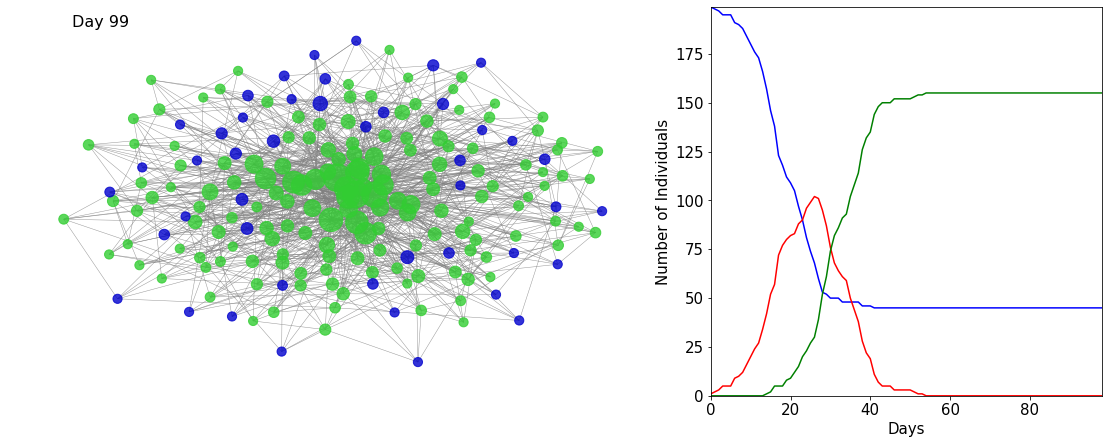

In [8]:
plt.rcParams['figure.figsize'] = [16, 9] 

colors_dict = {"S": "mediumblue",
               "I": "crimson",
               "R": "limegreen"}

fig, (ax1, ax2) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1.2]})
plt.margins(0,0)

camera = Camera(fig)
for i in range(len(daily_states)):
    colors = [colors_dict[state] for state in daily_states[i]]
    
    # make node sizes proportional to degree
    sizes = np.array(list((dict(model.degree()).values())))*14

    # plot network
    nx.draw(model, node_color = colors, node_size = sizes, 
            edge_color = "grey", alpha = 0.8, pos = positions,
            width = 0.5, ax=ax1)

    # plot SIR numbers over time
    plot_results(sim_S[:i], sim_I[:i], sim_R[:i], ax2)
    ax1.annotate(f"Day {i}", xy=(0.1,0.95), xycoords='axes fraction', fontsize=16)
    
    plt.subplots_adjust(top = 0.9, bottom = 0.3, 
                        right = 0.95, left = 0, 
                        hspace = 0, wspace = 0.1)
    camera.snap()
    
animation = camera.animate(interval = 300)
animation.save('epidemic_animation.gif', writer = 'imagemagick')